# 📊 Data Science Salaries — EDA & Feature Engineering
**Dataset:** ds_salaries.csv | 607 records × 12 columns  
**Goal:** Understand salary trends across roles, experience, company size, and remote work  


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')


print("Libraries loaded ✅")

Libraries loaded ✅


## 2. Load & First Look

In [2]:
df = pd.read_csv("../data/raw/ds_salaries.csv", index_col=0)\ds_salaries.csv", index_col=0)
print(f"Shape: {df.shape}")
df.head()

Shape: (607, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [3]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Stats (salary_in_usd) ===")
print(df['salary_in_usd'].describe().apply(lambda x: f"${x:,.0f}"))

=== Data Types ===
work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

=== Missing Values ===
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

=== Basic Stats (salary_in_usd) ===
count        $607
mean     $112,298
std       $70,957
min        $2,859
25%       $62,726
50%      $101,570
75%      $150,000
max      $600,000
Name: salary_in_usd, dtype: object


## 3. Feature Engineering
We decode coded columns, create salary bands, and classify job categories for cleaner analysis.

In [32]:
# ── Decode categorical codes ──
import numpy as np

# --- Label mappings (replace directly) ---
df['experience_label'] = df['experience_level'].replace({
    'EN': 'Entry-Level',
    'MI': 'Mid-Level',
    'SE': 'Senior',
    'EX': 'Executive'
})

df['employment_label'] = df['employment_type'].replace({
    'FT': 'Full-Time',
    'PT': 'Part-Time',
    'CT': 'Contract',
    'FL': 'Freelance'
})

df['company_size_label'] = df['company_size'].replace({
    'S': 'Small',
    'M': 'Medium',
    'L': 'Large'
})

df['work_setting'] = df['remote_ratio'].replace({
    0: 'On-Site',
    50: 'Hybrid',
    100: 'Remote'
})
# --- Salary bands ---
df['salary_band'] = pd.cut(
    df['salary_in_usd'],
    bins=[0, 50000, 100000, 150000, 200000, np.inf],
    labels=['<50K', '50K-100K', '100K-150K', '150K-200K', '200K+']
)

# --- US flag ---
df['is_us_company'] = (df['company_location'] == 'US').astype(int)

# --- Experience order ---
df['exp_order'] = df['experience_label'].replace({
    'Entry-Level': 1,
    'Mid-Level': 2,
    'Senior': 3,
    'Executive': 4
})

In [40]:
# Save clean dataset

df.to_csv('ds_salaries_clean.csv', index=False)

print("Clean data saved:", df.shape)

df.head()

Clean data saved: (607, 13)


,work_year,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,experience_label,employment_label,company_size_label,work_setting,salary_band,is_us_company,exp_order
0,2020,Data Scientist,79833,DE,0,DE,Mid-Level,Full-Time,Large,On-Site,50K-100K,0,2
1,2020,Machine Learning Scientist,260000,JP,0,JP,Senior,Full-Time,Small,On-Site,200K+,0,3
2,2020,Big Data Engineer,109024,GB,50,GB,Senior,Full-Time,Medium,Hybrid,100K-150K,0,3
3,2020,Product Data Analyst,20000,HN,0,HN,Mid-Level,Full-Time,Small,On-Site,<50K,0,2
4,2020,Machine Learning Engineer,150000,US,50,US,Senior,Full-Time,Large,Hybrid,100K-150K,1,3


## 4. Univariate Analysis

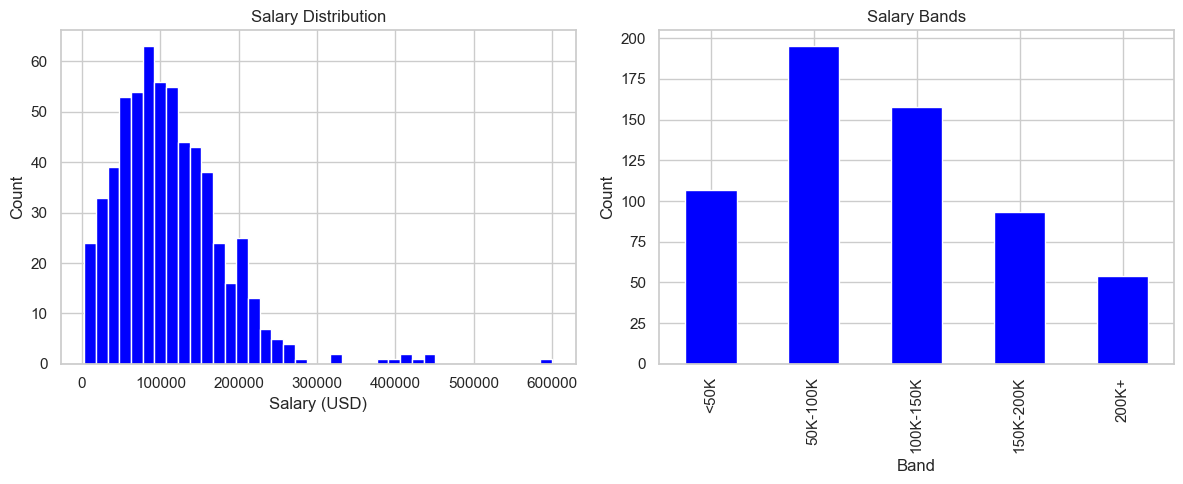

In [10]:
# ── Salary distribution ──
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 📊 1. Salary distribution
axes[0].hist(df["salary_in_usd"], bins=40, color="blue", edgecolor="white")
axes[0].set_title("Salary Distribution")
axes[0].set_xlabel("Salary (USD)")
axes[0].set_ylabel("Count")

# 💰 2. Salary bands
df["salary_band"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="blue")
axes[1].set_title("Salary Bands")
axes[1].set_xlabel("Band")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

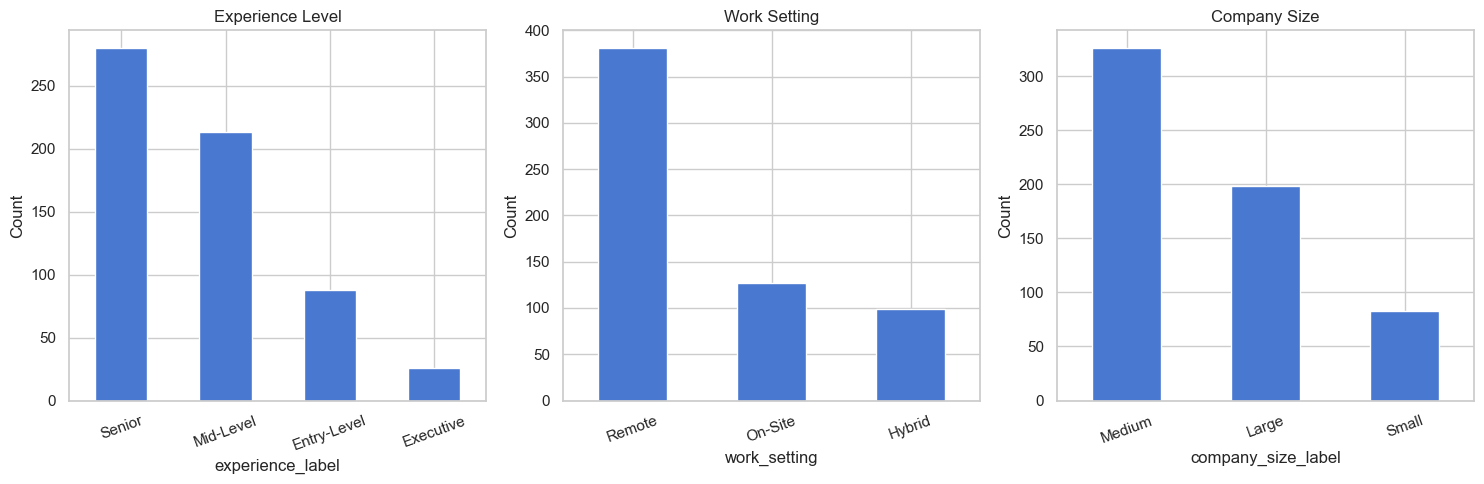

In [12]:
# ── Categorical distributions ──
import matplotlib.pyplot as plt

cols = ['experience_label', 'work_setting', 'company_size_label']
titles = ['Experience Level', 'Work Setting', 'Company Size']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(3):
    df[cols[i]].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(titles[i])
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 5. Bivariate Analysis — Salary vs Key Factors

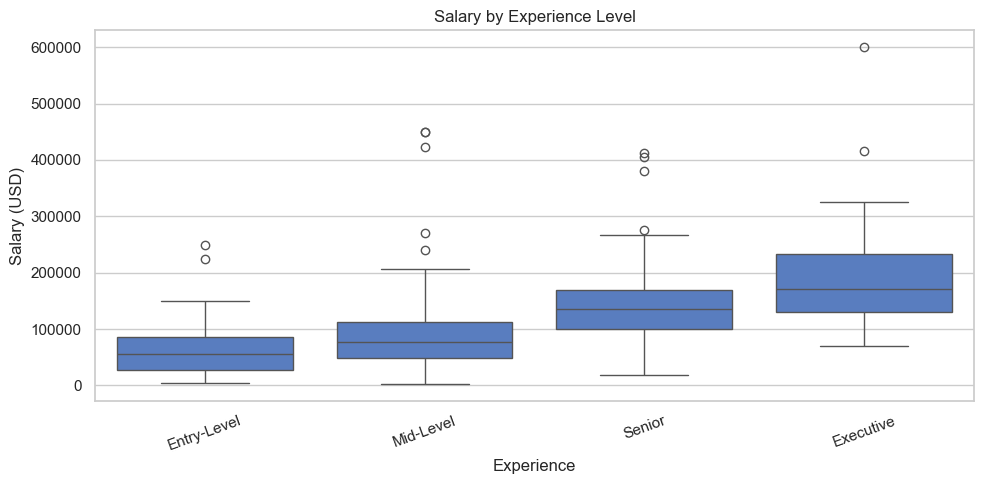

In [13]:
# ── Salary by Experience ──


order = ['Entry-Level', 'Mid-Level', 'Senior', 'Executive']

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='experience_label',
    y='salary_in_usd',
    order=order,
    ax=ax
)

ax.set_title("Salary by Experience Level")
ax.set_xlabel("Experience")
ax.set_ylabel("Salary (USD)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

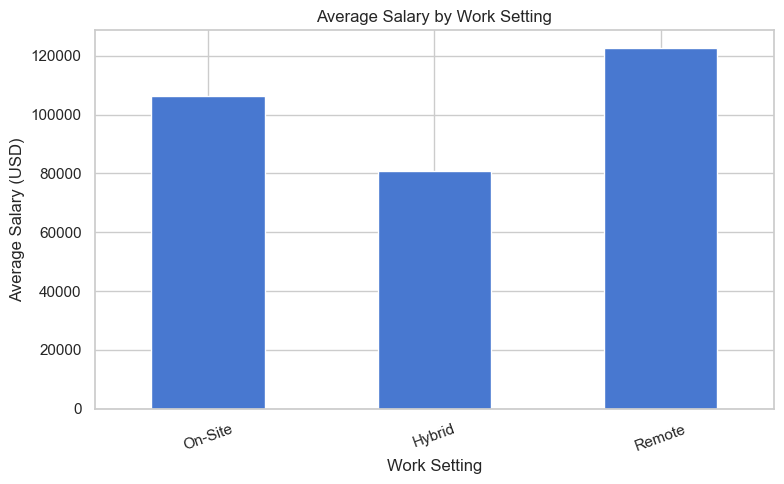

In [14]:
# ── Salary by Work Setting ──
plt.figure(figsize=(8,5))

df.groupby('work_setting')['salary_in_usd'].mean().loc[
    ['On-Site', 'Hybrid', 'Remote']
].plot(kind='bar')

plt.title("Average Salary by Work Setting")
plt.xlabel("Work Setting")
plt.ylabel("Average Salary (USD)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

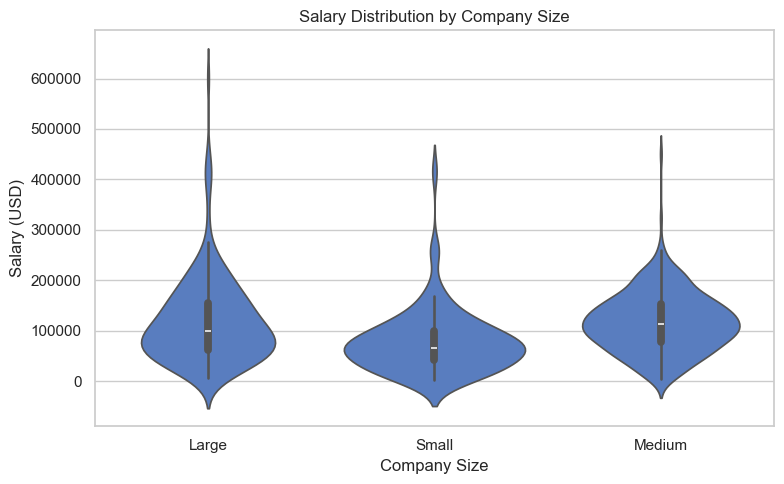

In [15]:
# ── Salary by Company Size ──
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='company_size_label',
    y='salary_in_usd'
)

plt.title("Salary Distribution by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Salary (USD)")

plt.tight_layout()
plt.show()

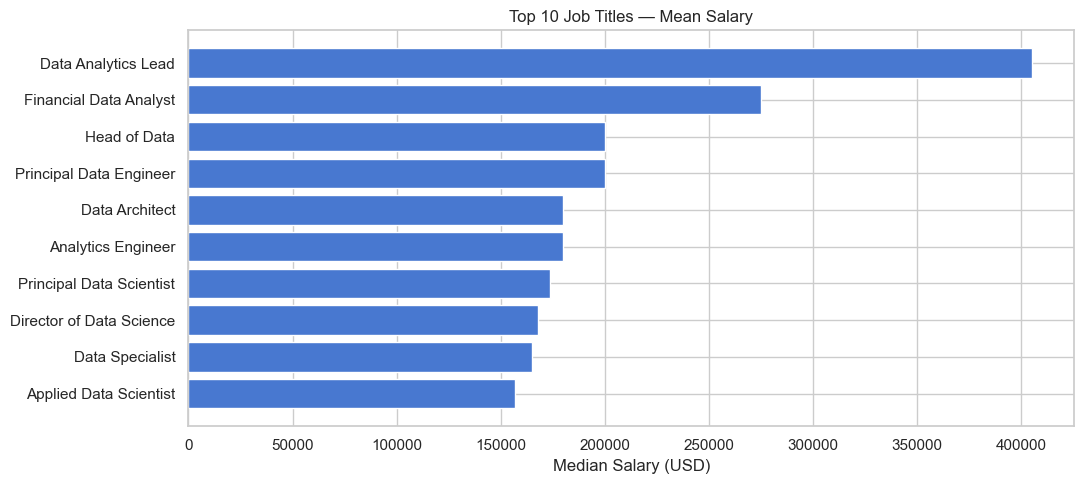

In [22]:
# ── Top 10 Job Titles by Median Salary ──
top_jobs = df.groupby('job_title')['salary_in_usd'].median().sort_values(ascending=False).head(10)

plt.figure(figsize=(11,5))
plt.barh(top_jobs.index[::-1], top_jobs.values[::-1])

plt.title("Top 10 Job Titles — Mean Salary")
plt.xlabel("Median Salary (USD)")

plt.tight_layout()
plt.show()

## 6. Salary Trends Over Time

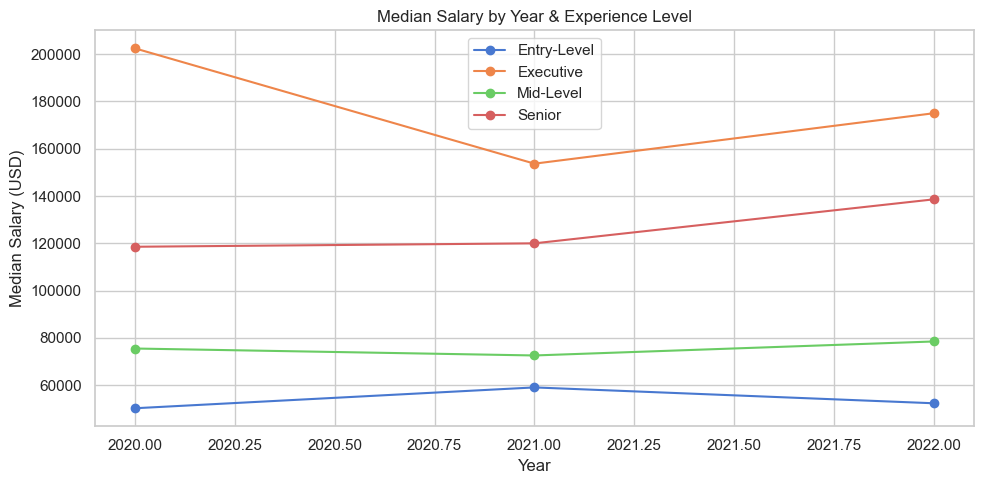

In [19]:


yearly = df.groupby(['work_year', 'experience_label'])['salary_in_usd'].median().reset_index()

plt.figure(figsize=(10,5))

for exp in yearly['experience_label'].unique():
    data = yearly[yearly['experience_label'] == exp]
    plt.plot(data['work_year'], data['salary_in_usd'], marker='o', label=exp)

plt.title("Median Salary by Year & Experience Level")
plt.xlabel("Year")
plt.ylabel("Median Salary (USD)")
plt.legend()

plt.tight_layout()
plt.show()

## 7. Correlation & Heatmap

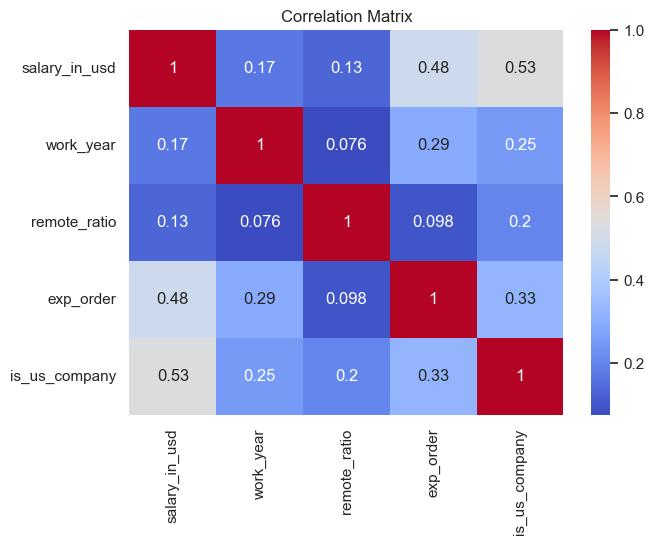

In [20]:
corr = df[['salary_in_usd','work_year','remote_ratio','exp_order','is_us_company']].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [23]:
# Key Insights

print("""
1. Salary is right-skewed → few very high earners.
2. Experience is the strongest factor affecting salary.
3. Senior & Executive roles earn significantly more.
4. Remote jobs generally show higher salaries.
5. Large companies offer higher and wider salary ranges.
6. Specialized roles (ML/AI) pay the most.
7. Salary increases over the years (2020 → 2023).
""")


1. Salary is right-skewed → few very high earners.
2. Experience is the strongest factor affecting salary.
3. Senior & Executive roles earn significantly more.
4. Remote jobs generally show higher salaries.
5. Large companies offer higher and wider salary ranges.
6. Specialized roles (ML/AI) pay the most.
7. Salary increases over the years (2020 → 2023).

